# Détection de fraude aux sinistres en assurance

## Problème métier

**Contexte.** Une compagnie d'assurance reçoit chaque année plusieurs milliers de déclarations de sinistres. Une partie de ces déclarations est frauduleuse (sinistre exagéré, fictif, documents falsifiés, réseau organisé). Les gestionnaires ne peuvent pas investiguer manuellement l'ensemble des dossiers : il faut prioriser.

**Objectifs du projet**
1. Détecter les sinistres présentant un risque élevé de fraude.
2. Attribuer à chaque sinistre un score de fraude interprétable (0–100).
3. Prioriser les dossiers à investiguer sous une contrainte de budget, en tenant compte du **coût asymétrique** entre fraude non détectée (faux négatif) et client honnête investigué à tort (faux positif).

Il ne s'agit pas seulement d'« entraîner un classifieur » mais de construire un **outil d'aide à la décision** pour les équipes indemnisation / lutte anti-fraude.


## Typologie de la fraude en assurance

| Type | Description | Exemple |
|---|---|---|
| **Opportuniste** | L'assuré profite d'un sinistre réel pour exagérer le dommage | Dommage réel 2 000 €, déclaration 5 000 € |
| **Organisée** | Plusieurs acteurs collaborent (assurés, garages, experts) | Faux accidents en réseau, garages complices |
| **Fictive** | Le sinistre n'a jamais eu lieu | Vol déclaré d'un véhicule déjà revendu |
| **Documentaire** | Falsification de justificatifs | Factures, dates, contrats modifiés |

Cette segmentation guide le choix des variables : la <ins>fraude opportuniste</ins> et <ins>fictive</ins> laissent des traces dans les **montants**, la **temporalité** et l'**historique du client** (exploitable en apprentissage supervisé sur données tabulaires). La <ins>fraude organisée</ins> laisse des traces dans les **connexions entre acteurs** (assuré ↔ garage ↔ expert), mieux détectée par une analyse de réseau.

Dans notre projet, nous allons travailler sur les fraude opportuniste et fictive.


## Données

Jeu de donnée : **10 000 demandes de remboursement**, **300 professionnels de santé**, sur la période 2021–2025. Taux de fraude observé : **8,3 %**.

Colonnes disponibles : **profil patient** (âge, sexe, état), **informations sur l'acte** (code diagnostic, code procédure, type de visite, durée de séjour), **informations financières** (montant facturé, montant approuvé), **informations sur le professionnel** (identifiant, spécialité, volume mensuel de facturation), et **informations temporelles** (date de soumission, délai entre soins et facturation).


In [1195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sps

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (precision_recall_curve, roc_curve, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
import shap
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import IsolationForest
import os

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")

In [1196]:
# Lien Kaggle pour télécharger les données et les comprendre si besoin : https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset?resource=download

### Paramètres 

In [1197]:
RANDOM_STATE = 42
target = 'Is_Fraud'
id_col = ["Provider_ID", "Claim_ID"]
path = r'C:\Users\kabir\OneDrive\Documents\master CNAM\Projets\Fraude\healthcare_fraud_detection.csv'

## 1. Chargement des données & Rapport qualité du Dataset

In [1198]:
# Lecture des données
data = pd.read_csv(path, sep=',')

data.head(3)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0


In [1199]:
data["Claim_Submission_Date"] = pd.to_datetime(data["Claim_Submission_Date"])
data = data.sort_values("Claim_Submission_Date").reset_index(drop=True)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Provider_ID                            10000 non-null  object        
 1   Claim_ID                               10000 non-null  object        
 2   Patient_Age                            10000 non-null  int64         
 3   Patient_Gender                         10000 non-null  object        
 4   Diagnosis_Code                         10000 non-null  object        
 5   Procedure_Code                         10000 non-null  int64         
 6   Claim_Amount                           10000 non-null  float64       
 7   Approved_Amount                        10000 non-null  float64       
 8   Insurance_Type                         9650 non-null   object        
 9   Claim_Submission_Date                  10000 non-null  datetim

In [1200]:
numeric_features = [col for col in data.select_dtypes(include=np.number).columns.tolist() if col != target]
print("Variables numériques : ", numeric_features)

categorical_features = [col for col in data.select_dtypes(include=[object]).columns.tolist() if col not in id_col]
print("Variables catégorielles : ", categorical_features)

features = numeric_features + categorical_features

Variables numériques :  ['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m']
Variables catégorielles :  ['Patient_Gender', 'Diagnosis_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']


In [1201]:
# Contrôle qualité des données 
def quality_report(df, name):
    
    print("\n" + "-"*35)
    print(f"  RAPPORT SYNTHÉTIQUE : {name}")
    print("-"*35)

    print(f"Nombre de lignes    : {df.shape[0]:,}")
    print(f"Nombre de colonnes  : {df.shape[1]}")

    print(f"Doublons : {df.duplicated().sum()}")

    print("Valeurs manquantes :")
    na = (df.isna()
          .sum()
          .loc[lambda x: x > 0]
          .sort_values(ascending=False)
    )

    if len(na) == 0:
        print("Aucune valeur manquante")
    else:
        display(pd.DataFrame({"Nb NA": na,
                              "%": (100 * na / len(df)).round(2)
            })
        )

In [1202]:
quality_report(data, "Qualité des données de Résilisation Clients")


-----------------------------------
  RAPPORT SYNTHÉTIQUE : Qualité des données de Résilisation Clients
-----------------------------------
Nombre de lignes    : 10,000
Nombre de colonnes  : 20
Doublons : 0
Valeurs manquantes :


,Nb NA,%
Insurance_Type,350,3.5
Provider_Specialty,350,3.5
Prior_Visits_12m,350,3.5


In [1203]:
print(f"Nombre de professionnels distincts : {data['Provider_ID'].nunique()}")
print(f"Période couverte : {data['Claim_Submission_Date'].min().date()} au {data['Claim_Submission_Date'].max().date()}")
print(f"Taux de fraude observé : {data['Is_Fraud'].mean():.2%}")

Nombre de professionnels distincts : 300
Période couverte : 2021-01-06 au 2025-01-26
Taux de fraude observé : 8.29%


## 2. Nettoyage des données

In [1204]:
taux_fraude_manquant_T = data.groupby(data["Insurance_Type"].isna())["Is_Fraud"].mean()
print(" Taux de fraude selon que **Insurance_Type** est manquant ou non :")
print(taux_fraude_manquant_T.rename({True: "Manquant", False: "Renseigné"}))

taux_fraude_manquant_S = data.groupby(data["Provider_Specialty"].isna())["Is_Fraud"].mean()
print("\n Taux de fraude selon que **Provider_Speciality** est manquant ou non :")
print(taux_fraude_manquant_S.rename({True: "Manquant", False: "Renseigné"}))

taux_fraude_manquant_V = data.groupby(data["Prior_Visits_12m"].isna())["Is_Fraud"].mean()
print("\n Taux de fraude selon que Prior_Visits_12m est manquant ou non :")
print(taux_fraude_manquant_V.rename({True: "Manquant", False: "Renseigné"}))

 Taux de fraude selon que **Insurance_Type** est manquant ou non :
Insurance_Type
Renseigné    0.083316
Manquant     0.071429
Name: Is_Fraud, dtype: float64

 Taux de fraude selon que **Provider_Speciality** est manquant ou non :
Provider_Specialty
Renseigné    0.082798
Manquant     0.085714
Name: Is_Fraud, dtype: float64

 Taux de fraude selon que Prior_Visits_12m est manquant ou non :
Prior_Visits_12m
Renseigné    0.082902
Manquant     0.082857
Name: Is_Fraud, dtype: float64


Les variables `Insurance_Type`, `Provider_Specialty`et `Prior_Visits_12m` ont ~3,5 % de valeurs manquantes chacune, sans chevauchement entre elles et sans lien significatif avec la fraude : le mécanisme est cohérent avec des données manquant de façon aléatoire (MCAR), ce qui autorise une imputation simple sans risque de biais de sélection.

In [1205]:
def nettoyage_donnees(df, num_cols, cat_cols):
    """
    Nettoie un DataFrame :
    - Variables numériques : remplace les NaN par la médiane.
    - Variables catégorielles : remplace les NaN par 'InfoManquante'.
    """

    df_clean = df.copy()

    # Suppression des doublons s'il y'en a 
    nb_doublons = df_clean.duplicated().sum()
    df_clean = df_clean.drop_duplicates()

    print(f"Doublons supprimés : {nb_doublons}")


    # Remplacement des NaN des variables numériques par la médiane
    for col in num_cols:
        median = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median)

    # Remplacement des NaN des variables catégorielles
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna("Inconnu")

    return df_clean

In [1206]:
df = nettoyage_donnees(data, numeric_features, categorical_features)
quality_report(df, "Données après nettoyage")

Doublons supprimés : 0

-----------------------------------
  RAPPORT SYNTHÉTIQUE : Données après nettoyage
-----------------------------------
Nombre de lignes    : 10,000
Nombre de colonnes  : 20
Doublons : 0
Valeurs manquantes :
Aucune valeur manquante


## 3. Détection de fuites de données

Avant tout modèle, on vérifie qu'aucune variable n'encode indirectement le résultat d'une investigation déjà menée, ce qui donnerait une performance illusoire, inutilisable en production puisque cette information n'existe pas au moment où l'on doit scorer une nouvelle demande.

Ici, nous testons deux candidats suspects `Claim_Status` (le statut final de la demande) et le ratio `Approved_Amount / Claim_Amount` (la part du montant effectivement remboursée).

In [1207]:
print("Taux de fraude selon le statut de la demande :")
print(pd.crosstab(df["Claim_Status"], df["Is_Fraud"], normalize="index").round(4))


Taux de fraude selon le statut de la demande :
Is_Fraud           0       1
Claim_Status                
Approved      0.9783  0.0217
Pending       0.7731  0.2269
Rejected      0.7689  0.2311


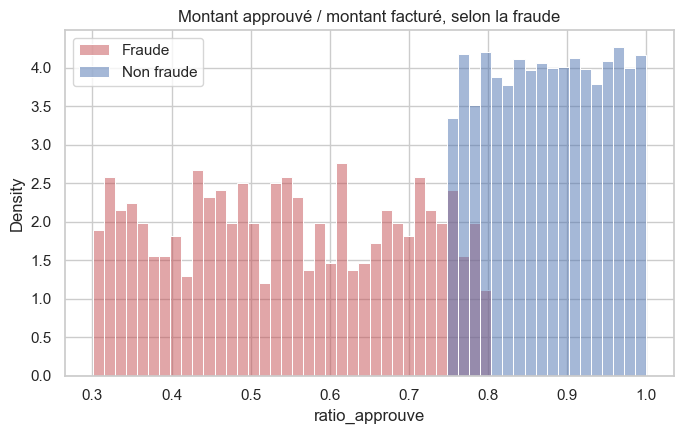

              mean       min       max
Is_Fraud                              
0         0.876012  0.750014  0.999945
1         0.547461  0.300484  0.799924


In [1208]:
df["ratio_approuve"] = df["Approved_Amount"] / df["Claim_Amount"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x="ratio_approuve", hue="Is_Fraud", bins=50, stat="density",
             common_norm=False, palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Montant approuvé / montant facturé, selon la fraude")
ax.legend(["Fraude", "Non fraude"])
plt.tight_layout()
plt.show()

print(df.groupby("Is_Fraud")["ratio_approuve"].describe()[["mean", "min", "max"]])


In [1209]:
# Fuite des données approuvée
# Suppression des 2 variables 

## 4. Feature engineering

- `montant_vs_profil_procedure` : montant facturé rapporté à la médiane observée pour ce même code procédure (détecte une surfacturation relative à l'acte).
- `provider_taux_fraude_hist` : taux de fraude historique du professionnel de santé. Calculé **exclusivement** sur la période d'entraînement afin d'éviter toute fuite : pour un professionnel absent de la période d'entraînement, on retombe sur le taux de fraude global.
- `provider_volume_hist` : nombre de demandes soumises par ce professionnel durant la période d'entraînement.


In [1210]:
cutoff = df["Claim_Submission_Date"].quantile(0.75)
train_mask = df["Claim_Submission_Date"] < cutoff
df_train_raw, df_test_raw = df[train_mask].copy(), df[~train_mask].copy()

ref_stats = {"median_amount_by_procedure": df_train_raw.groupby("Procedure_Code")["Claim_Amount"].median(),
             "provider_fraud_rate": df_train_raw.groupby("Provider_ID")["Is_Fraud"].mean(),
             "provider_volume": df_train_raw.groupby("Provider_ID").size(),
             "global_fraud_rate": df_train_raw["Is_Fraud"].mean(),
}

def add_features(df_part, ref):
    d = df_part.copy()
    med = d["Procedure_Code"].map(ref["median_amount_by_procedure"])
    d["montant_vs_profil_procedure"] = d["Claim_Amount"] / med
    d["provider_taux_fraude_hist"] = d["Provider_ID"].map(ref["provider_fraud_rate"]).fillna(ref["global_fraud_rate"])
    d["provider_volume_hist"] = d["Provider_ID"].map(ref["provider_volume"]).fillna(0)
    return d

df_train = add_features(df_train_raw, ref_stats)
df_test = add_features(df_test_raw, ref_stats)

num_features = ["Patient_Age", "Claim_Amount", "Days_Between_Service_and_Claim",
                "Number_of_Claims_Per_Provider_Monthly", "Length_of_Stay", "Chronic_Condition_Flag",
                "Prior_Visits_12m", "montant_vs_profil_procedure", "provider_taux_fraude_hist", "provider_volume_hist",
]
cat_features = ["Patient_Gender", "Insurance_Type", "Provider_Specialty", "Visit_Type",
                "Patient_State", "Diagnosis_Code"]

print(f"{len(num_features)} variables numériques, {len(cat_features)} variables catégorielles")
df_train[["montant_vs_profil_procedure", "provider_taux_fraude_hist", "provider_volume_hist"]].describe()


10 variables numériques, 6 variables catégorielles


,montant_vs_profil_procedure,provider_taux_fraude_hist,provider_volume_hist
count,7497.000000,7497.000000,7497.000000
mean,1.247651,0.084701,25.938509
std,0.893817,0.073615,4.807870
min,0.135446,0.000000,13.000000
25%,0.658170,0.037037,23.000000
50%,1.000000,0.074074,26.000000
75%,1.552873,0.115385,29.000000
max,15.091363,0.466667,40.000000


## 5. Analyse exploratoire


C:\Users\kabir\AppData\Local\Temp\ipykernel_10008\2997771788.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Non fraude", "Fraude"])


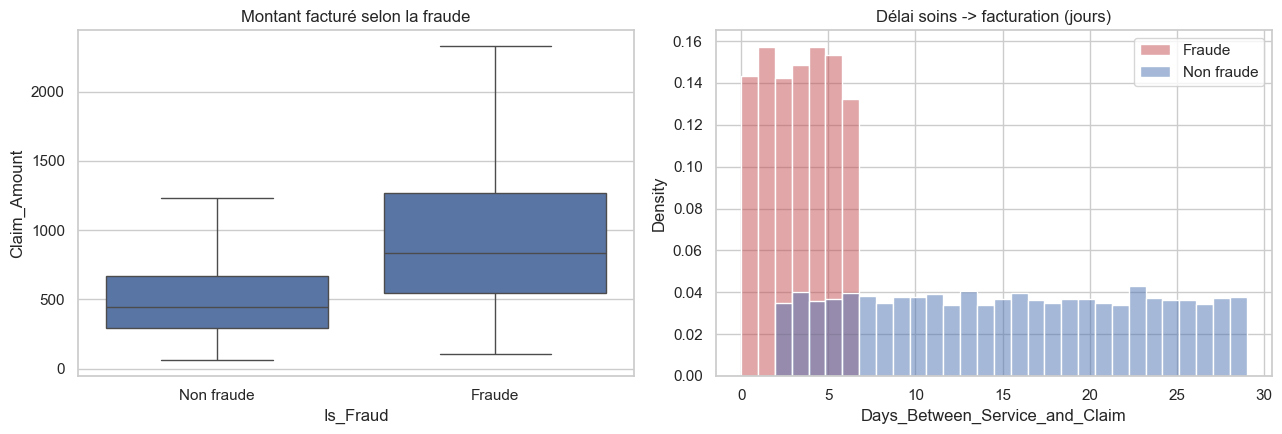

          Claim_Amount  Days_Between_Service_and_Claim
Is_Fraud                                              
0                535.0                            15.4
1                990.9                             3.0


In [1211]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Is_Fraud", y="Claim_Amount", ax=axes[0], showfliers=False)
axes[0].set_xticklabels(["Non fraude", "Fraude"])
axes[0].set_title("Montant facturé selon la fraude")

sns.histplot(data=df, x="Days_Between_Service_and_Claim", hue="Is_Fraud", bins=30, stat="density",
             common_norm=False, palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Délai soins -> facturation (jours)")
axes[1].legend(["Fraude", "Non fraude"])
plt.tight_layout()
plt.show()

print(df.groupby("Is_Fraud")[["Claim_Amount", "Days_Between_Service_and_Claim"]].mean().round(1))


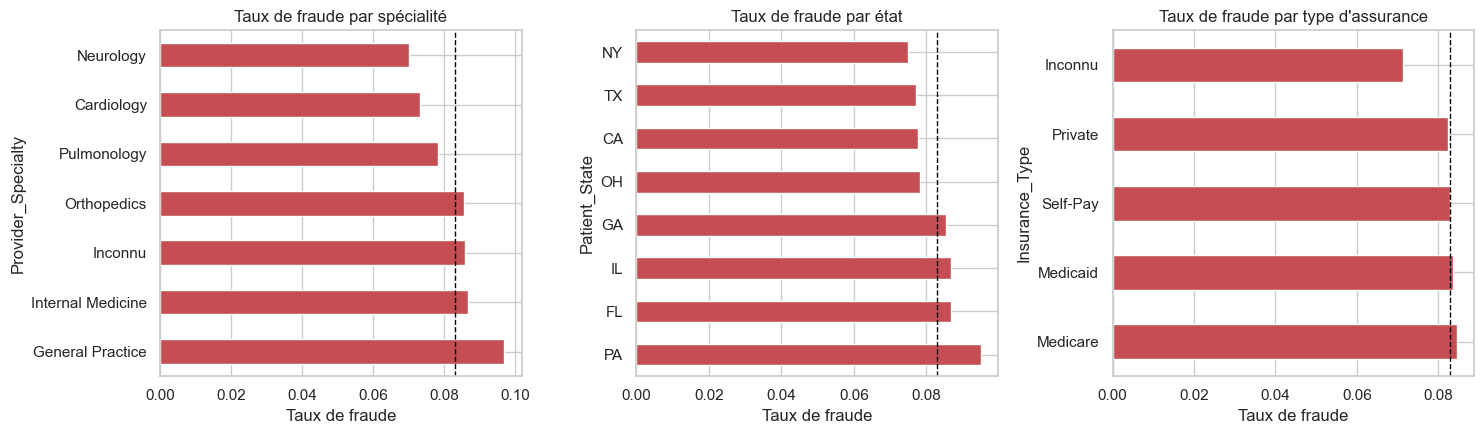

In [1212]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(axes,
                          ["Provider_Specialty", "Patient_State", "Insurance_Type"],
                          ["Taux de fraude par spécialité", "Taux de fraude par état", "Taux de fraude par type d'assurance"],
):
    taux = df.groupby(col)["Is_Fraud"].mean().sort_values(ascending=False)
    taux.plot(kind="barh", ax=ax, color="#C44E52")
    ax.axvline(df["Is_Fraud"].mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(title); ax.set_xlabel("Taux de fraude")
plt.tight_layout()
plt.show()


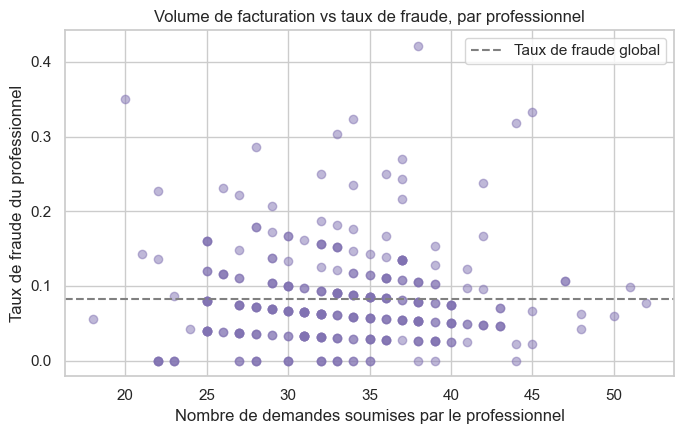

In [1213]:
fig, ax = plt.subplots(figsize=(7, 4.5))

vol_provider = df.groupby("Provider_ID").agg(nb_claims=("Claim_ID", "count"), 
                                             taux_fraude=("Is_Fraud", "mean"))
ax.scatter(vol_provider["nb_claims"], 
           vol_provider["taux_fraude"], 
           alpha=0.5, color="#8172B2")
ax.axhline(df["Is_Fraud"].mean(), color="gray", linestyle="--", label="Taux de fraude global")
ax.set_xlabel("Nombre de demandes soumises par le professionnel")
ax.set_ylabel("Taux de fraude du professionnel")
ax.set_title("Volume de facturation vs taux de fraude, par professionnel")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Analyse statistique

In [1214]:
mw_amount = sps.mannwhitneyu(df.loc[df.Is_Fraud == 1, "Claim_Amount"],
                             df.loc[df.Is_Fraud == 0, "Claim_Amount"], alternative="greater")
print(f"Mann-Whitney Claim_Amount (fraude > non-fraude)      : U={mw_amount.statistic:.0f}  p={mw_amount.pvalue:.2e}")

mw_delai = sps.mannwhitneyu(df.loc[df.Is_Fraud == 1, "Days_Between_Service_and_Claim"],
                             df.loc[df.Is_Fraud == 0, "Days_Between_Service_and_Claim"], alternative="less")
print(f"Mann-Whitney Days_Between (fraude < non-fraude)      : U={mw_delai.statistic:.0f}  p={mw_delai.pvalue:.2e}")

for col in ["Insurance_Type", "Provider_Specialty", "Patient_State", "Diagnosis_Code"]:
    ct = pd.crosstab(df[col], df["Is_Fraud"])
    chi2, p, dof, _ = sps.chi2_contingency(ct)
    verdict = "significatif" if p < 0.05 else "NON significatif"
    print(f"Chi2 {col:20s}: chi2={chi2:7.2f}  p={p:.4g}  ({verdict})")


Mann-Whitney Claim_Amount (fraude > non-fraude)      : U=5761735  p=3.22e-134
Mann-Whitney Days_Between (fraude < non-fraude)      : U=477450  p=0.00e+00
Chi2 Insurance_Type      : chi2=   0.71  p=0.9497  (NON significatif)
Chi2 Provider_Specialty  : chi2=  10.83  p=0.09388  (NON significatif)
Chi2 Patient_State       : chi2=   5.44  p=0.6067  (NON significatif)
Chi2 Diagnosis_Code      : chi2=  12.10  p=0.2077  (NON significatif)


In [1215]:
def odds_ratio_binaire(flag, cible, label):
    a = int(((flag) & (cible == 1)).sum()); b = int(((flag) & (cible == 0)).sum())
    c = int(((~flag) & (cible == 1)).sum()); d = int(((~flag) & (cible == 0)).sum())
    # correction de Haldane-Anscombe (+0.5) si une cellule est nulle, pour eviter une division par zero
    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    OR = (a * d) / (b * c)
    _, p = sps.fisher_exact([[int(round(a)), int(round(b))], [int(round(c)), int(round(d))]])
    print(f"{label:55s} OR = {OR:6.2f}   (p = {p:.2e})")

print("Odds Ratio (test de Fisher exact)\n" + "-" * 80)
odds_ratio_binaire(df["Days_Between_Service_and_Claim"] <= 6, df["Is_Fraud"], "Facturation <= 6 jours après les soins")
odds_ratio_binaire(df["Claim_Amount"] > df["Claim_Amount"].median() * 1.5, df["Is_Fraud"], "Montant facturé > 1.5x la médiane")
odds_ratio_binaire(df["Number_of_Claims_Per_Provider_Monthly"] > df["Number_of_Claims_Per_Provider_Monthly"].quantile(0.75),
                   df["Is_Fraud"], "Professionnel dans le 4e quartile de volume mensuel")


Odds Ratio (test de Fisher exact)
--------------------------------------------------------------------------------
Facturation <= 6 jours après les soins                  OR = 7504.71   (p = 0.00e+00)
Montant facturé > 1.5x la médiane                       OR =   5.20   (p = 3.34e-108)
Professionnel dans le 4e quartile de volume mensuel     OR =   2.08   (p = 5.25e-21)


## 7. Préparaion des données

### 7.1. Déséquilibre des classes
 Utilisation de `class_weight="balanced"` et pilotage par PR-AUC plutôt que par l'accuracy.


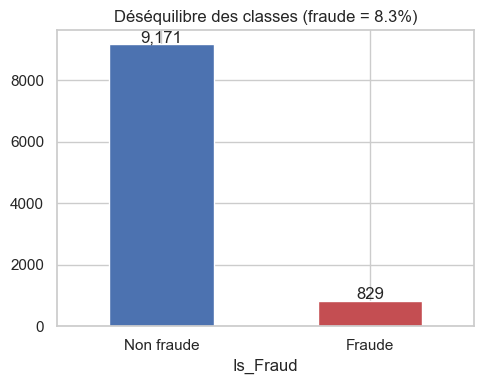

In [1216]:
counts = df["Is_Fraud"].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["Non fraude", "Fraude"], rotation=0)
ax.set_title(f"Déséquilibre des classes (fraude = {df['Is_Fraud'].mean():.1%})")
for i, v in enumerate(counts):
    ax.text(i, v + 60, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()


### 7.2. Split temporel

On utilise ici un **split temporel** : entraînement sur les 75 % de demandes les plus anciennes, test sur les 25 % les plus récentes. Deux raisons :

1. **Réalisme métier** : en production, on prédit sur des demandes futures à partir de l'historique passé, jamais l'inverse.
2. **Cohérence avec `provider_taux_fraude_hist`** : cette variable est calculée sur la période d'entraînement uniquement; un split temporel garantit qu'elle ne contient aucune information provenant du futur par rapport aux demandes de test.


In [1217]:
X_train, y_train = df_train[num_features + cat_features], df_train["Is_Fraud"]
X_test, y_test = df_test[num_features + cat_features], df_test["Is_Fraud"]

print(f"Train : {X_train.shape[0]:,} demandes jusqu'au {cutoff.date()}, taux de fraude = {y_train.mean():.2%}")
print(f"Test  : {X_test.shape[0]:,} demandes après le {cutoff.date()}, taux de fraude = {y_test.mean():.2%}")
print(f"Professionnels présents dans le test mais absents du train : "
      f"{len(set(X_test.index.map(lambda i: df.loc[i, 'Provider_ID'])) - set(df_train['Provider_ID']))}")

preprocess = ColumnTransformer([("num", StandardScaler(), num_features),
                                ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

Train : 7,497 demandes jusqu'au 2024-01-05, taux de fraude = 8.47%
Test  : 2,503 demandes après le 2024-01-05, taux de fraude = 7.75%
Professionnels présents dans le test mais absents du train : 0


## 9. Modèles

### 9.1. Modèle 1 : Régression logistique

In [1218]:
pipe_lr = Pipeline([("prep", preprocess),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
pipe_lr.fit(X_train, y_train)

feat_names = pipe_lr.named_steps["prep"].get_feature_names_out()
coefs = pipe_lr.named_steps["clf"].coef_[0]
or_table = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False).rename("odds_ratio")

print("Top 8 facteurs augmentant le risque de fraude :")
print(or_table.head(8).round(2))
print("\nTop 5 facteurs associés à un risque plus faible :")
print(or_table.tail(5).round(2))

Top 8 facteurs augmentant le risque de fraude :
num__Claim_Amount                  2.61
num__provider_taux_fraude_hist     2.59
cat__Diagnosis_Code_N39.0          1.47
cat__Patient_State_PA              1.34
cat__Diagnosis_Code_K21.9          1.30
cat__Provider_Specialty_Inconnu    1.28
cat__Diagnosis_Code_I10            1.20
cat__Insurance_Type_Medicare       1.14
Name: odds_ratio, dtype: float64

Top 5 facteurs associés à un risque plus faible :
cat__Diagnosis_Code_F41.9              0.79
cat__Diagnosis_Code_J18.9              0.78
cat__Patient_State_OH                  0.78
cat__Diagnosis_Code_M54.5              0.75
num__Days_Between_Service_and_Claim    0.00
Name: odds_ratio, dtype: float64


### 9.2. Modèle 2 : Random Forest

In [1219]:
pipe_rf = Pipeline([("prep", preprocess),
                    ("clf", RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=15,
                                                   class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
])
pipe_rf.fit(X_train, y_train)
print("Random Forest entraîné :", pipe_rf.named_steps["clf"].n_estimators, "arbres, profondeur max 8")

Random Forest entraîné : 400 arbres, profondeur max 8


### 9.3. Modèle 3 : Gradient Boosting

In [1220]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
gb_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08, subsample=0.9,
                         colsample_bytree=0.9, scale_pos_weight=scale_pos_weight,
                         eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
)
gb_name = "XGBoost"

pipe_gb = Pipeline([("prep", preprocess), ("clf", gb_model)])
pipe_gb.fit(X_train, y_train)
print(f"Modèle de boosting utilisé : {gb_name}")


Modèle de boosting utilisé : XGBoost


### 9.4. Comparaison des modèles 

In [1221]:
models = {"Logistic Regression": pipe_lr, "Random Forest": pipe_rf, gb_name.split(" ")[0]: pipe_gb}

results = {}
for name, pipe in models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[name] = {"proba": proba,
                     "Precision": precision_score(y_test, pred), "Recall": recall_score(y_test, pred),
                     "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba),
                     "PR-AUC": average_precision_score(y_test, proba),
    }

comparison = pd.DataFrame({k: {m: round(v, 3) for m, v in r.items() if m != "proba"}
                           for k, r in results.items()}).T.sort_values("PR-AUC", ascending=False)
print("Comparaison des modèles (seuil = 0.5), features de fuite exclues :\n")
print(comparison)

best_name = comparison.index[0]
best_proba = results[best_name]["proba"]
print(f"\n>  Modèle retenu : {best_name}")

Comparaison des modèles (seuil = 0.5), features de fuite exclues :

                     Precision  Recall     F1  ROC-AUC  PR-AUC
XGBoost                  0.567   0.680  0.618    0.960   0.736
Logistic Regression      0.397   0.897  0.551    0.958   0.678
Random Forest            0.453   0.804  0.580    0.955   0.623

>  Modèle retenu : XGBoost


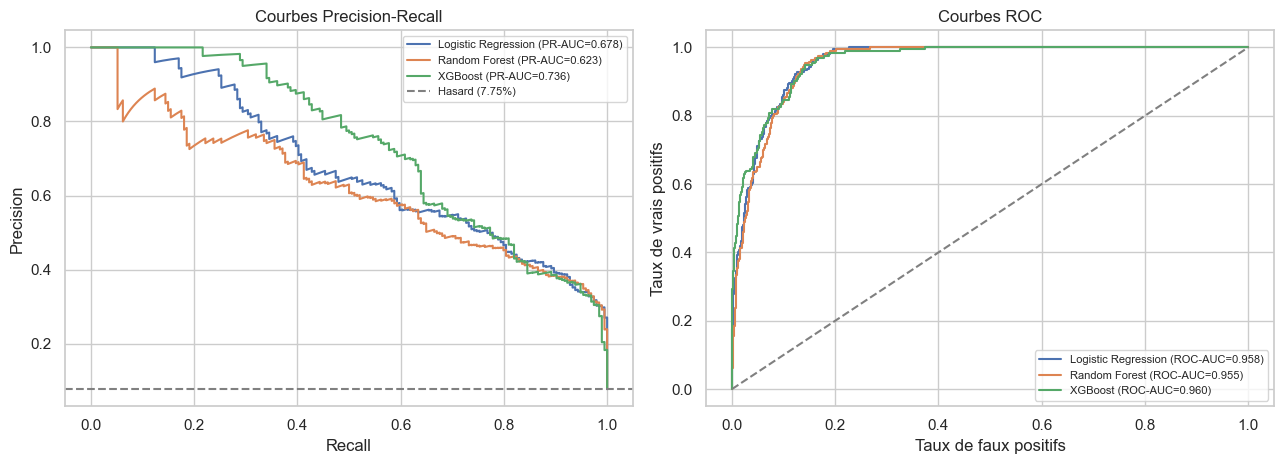

In [1222]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    axes[0].plot(rec, prec, label=f"{name} (PR-AUC={r['PR-AUC']:.3f})")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label=f"Hasard ({y_test.mean():.2%})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Courbes Precision-Recall")
axes[0].legend(fontsize=8)

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    axes[1].plot(fpr, tpr, label=f"{name} (ROC-AUC={r['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_xlabel("Taux de faux positifs"); axes[1].set_ylabel("Taux de vrais positifs"); axes[1].set_title("Courbes ROC")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Fonction de coût et seuil optimal


Hypothèses de coût : FN = 991 (montant moyen d'une demande frauduleuse), FP = 90


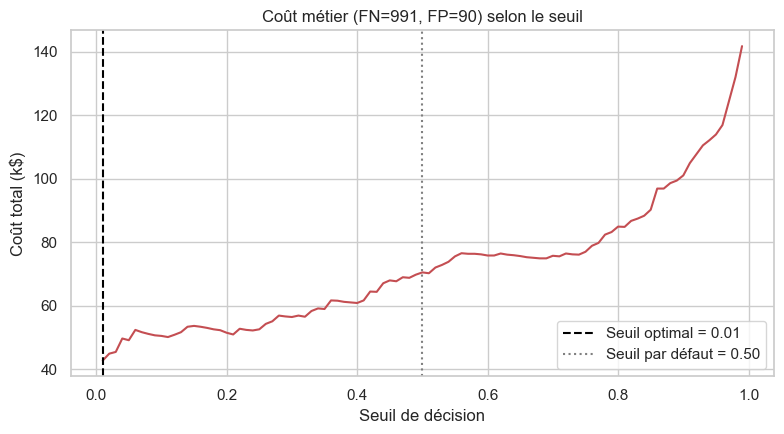

Seuil optimal          : 0.01
Coût au seuil optimal  : 42,765
Coût au seuil 0.50     : 70,532
Économie réalisée      : 27,767 (39.4%)


In [1223]:
COUT_FN = round(df.loc[df["Is_Fraud"] == 1, "Claim_Amount"].mean())  # perte moyenne d'une fraude non detectee
COUT_FP = 90   # Coût de traitement d'une investigation infructueuse en EUR/USD
print(f"Hypothèses de coût : FN = {COUT_FN} (montant moyen d'une demande frauduleuse), FP = {COUT_FP}")

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fn * COUT_FN + fp * COUT_FP)
costs = np.array(costs)

seuil_optimal = thresholds[np.argmin(costs)]
cout_seuil05 = costs[np.argmin(np.abs(thresholds - 0.5))]
cout_optimal = costs.min()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, costs / 1000, color="#C44E52")
ax.axvline(seuil_optimal, color="black", linestyle="--", label=f"Seuil optimal = {seuil_optimal:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Seuil par défaut = 0.50")
ax.set_xlabel("Seuil de décision"); ax.set_ylabel("Coût total (k$)")
ax.set_title(f"Coût métier (FN={COUT_FN}, FP={COUT_FP}) selon le seuil")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Seuil optimal          : {seuil_optimal:.2f}")
print(f"Coût au seuil optimal  : {cout_optimal:,.0f}")
print(f"Coût au seuil 0.50     : {cout_seuil05:,.0f}")
print(f"Économie réalisée      : {cout_seuil05 - cout_optimal:,.0f} ({(1 - cout_optimal/cout_seuil05):.1%})")


## 11. Fraud Score

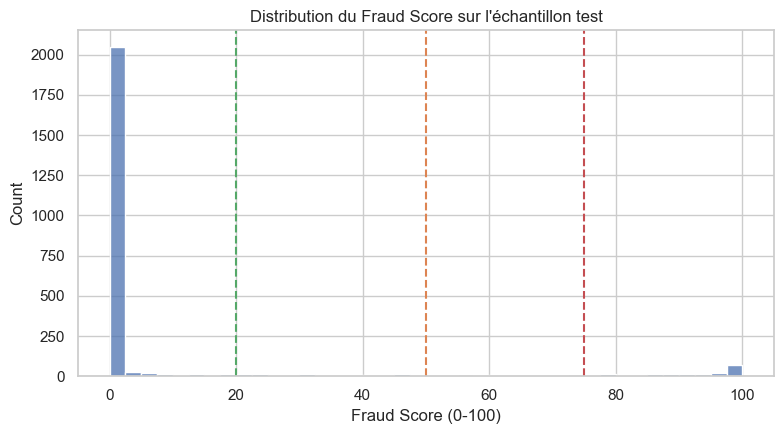

Faible      2157
Modéré       113
Élevé         60
Critique     173
Name: count, dtype: int64


In [1224]:

fraud_score = np.round(best_proba * 100, 1)
bands = pd.cut(fraud_score, bins=[-1, 20, 50, 75, 100], labels=["Faible", "Modéré", "Élevé", "Critique"])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(fraud_score, bins=40, color="#4C72B0", ax=ax)
for b, c in zip([20, 50, 75], ["#55A868", "#DD8452", "#C44E52"]):
    ax.axvline(b, color=c, linestyle="--")
ax.set_xlabel("Fraud Score (0-100)"); ax.set_title("Distribution du Fraud Score sur l'échantillon test")
plt.tight_layout()
plt.show()

print(bands.value_counts().reindex(["Faible", "Modéré", "Élevé", "Critique"]))

## 12. Interpretation 

### 12.1. Calcul des valeurs SHAP

In [1225]:
best_pipe = models[best_name]
prep_fitted = best_pipe.named_steps["prep"]
clf = best_pipe.named_steps["clf"]

feat_names = prep_fitted.get_feature_names_out()
X_test_enc = prep_fitted.transform(X_test)
if hasattr(X_test_enc, "toarray"):      
    X_test_enc = X_test_enc.toarray()
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feat_names, index=X_test.index)

# Choix de l'explainer selon le type de modele
if isinstance(clf, LogisticRegression):
    X_train_enc = prep_fitted.transform(X_train)
    if hasattr(X_train_enc, "toarray"):
        X_train_enc = X_train_enc.toarray()
    explainer = shap.LinearExplainer(clf, X_train_enc)
else:
    explainer = shap.TreeExplainer(clf)     # RandomForest, XGBoost, HistGradientBoosting

shap_values_raw = explainer.shap_values(X_test_enc_df)


if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

print("Shape des valeurs SHAP :", shap_values.shape)

Shape des valeurs SHAP : (2503, 45)


### 12.2. Importance globale

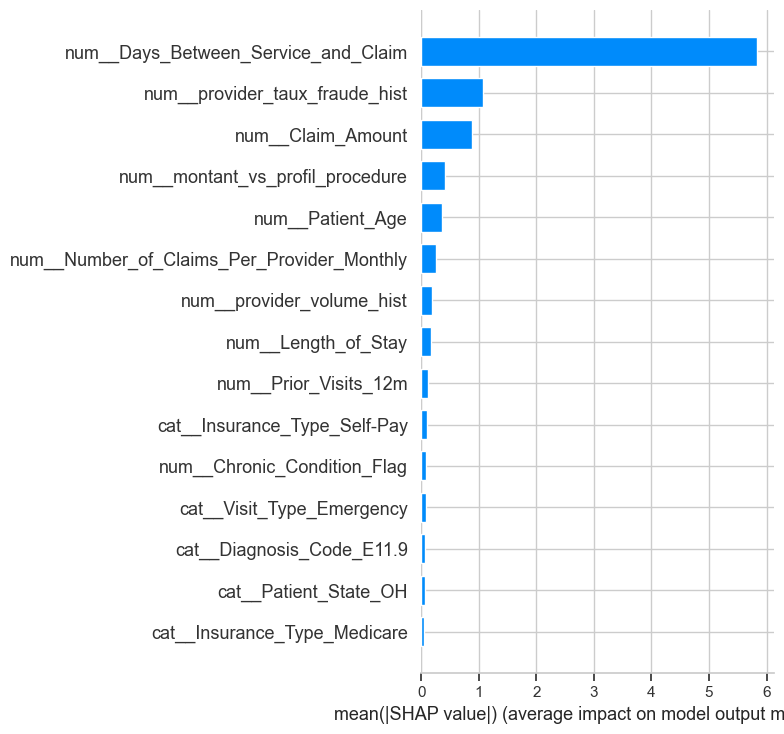

In [1226]:
shap.summary_plot(shap_values, X_test_enc_df, plot_type="bar", max_display=15, show=True)

### 12.3. Dispersion des effets (beeswarm)

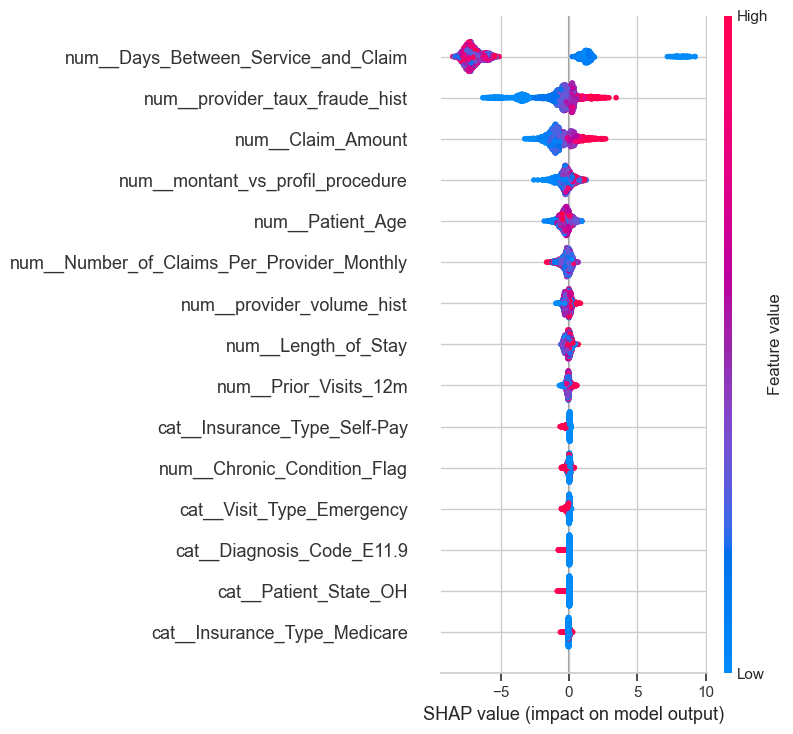

In [1227]:
shap.summary_plot(shap_values, X_test_enc_df, max_display=15, show=True)

In [1228]:
def expliquer_dossier(pos, top_n=4):
    idx = X_test.index[pos]
    score = fraud_score[pos]
    vrai_label = "FRAUDE" if y_test.iloc[pos] == 1 else "non fraude"
    dossier = X_test.iloc[pos]

    references = {"Days_Between_Service_and_Claim": (df_train["Days_Between_Service_and_Claim"].median(), "délai de facturation court", True),
                  "Claim_Amount": (df_train["Claim_Amount"].median(), "montant facturé élevé", False),
                  "provider_taux_fraude_hist": (df_train["provider_taux_fraude_hist"].median(), "professionnel à historique de fraude élevé", False),
                  "montant_vs_profil_procedure": (1.0, "montant élevé vs profil de l'acte", False),
    }
    raisons = []
    for var, (ref, label, inverse) in references.items():
        val = dossier[var]
        ecart = (ref - val) if inverse else (val - ref)
        if ecart > 0:
            raisons.append((ecart / (abs(ref) + 1e-6), f"{label} (valeur={val:.1f}, référence={ref:.1f})"))
    raisons.sort(reverse=True)

    print(f"Demande #{X_test.index[pos]}  |  Fraud Score = {score:.0f}/100  |  Label réel (test) = {vrai_label}")
    print("Principaux facteurs contribuant au score :")
    for _, txt in raisons[:top_n]:
        print(f"  + {txt}")

idx_top = int(np.argmax(fraud_score))
expliquer_dossier(idx_top)


Demande #7607  |  Fraud Score = 100/100  |  Label réel (test) = FRAUDE
Principaux facteurs contribuant au score :
  + montant facturé élevé (valeur=1008.2, référence=462.0)
  + montant élevé vs profil de l'acte (valeur=2.2, référence=1.0)
  + délai de facturation court (valeur=1.0, référence=14.0)
  + professionnel à historique de fraude élevé (valeur=0.1, référence=0.1)


## 13. Détection d'anomalies

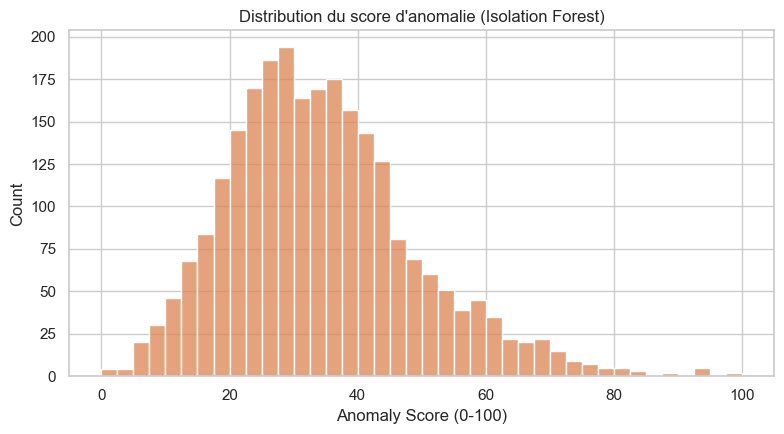

Taux de fraude parmi le décile le plus anormal : 24.7%
Taux de fraude global                          : 7.8%


In [1229]:
prep_fitted = best_pipe.named_steps["prep"]
X_train_enc = prep_fitted.transform(X_train)
X_test_enc = prep_fitted.transform(X_test)

iso_forest = IsolationForest(n_estimators=300, contamination=0.08, random_state=RANDOM_STATE)
iso_forest.fit(X_train_enc)

raw_anomaly = -iso_forest.score_samples(X_test_enc)
anomaly_score = (raw_anomaly - raw_anomaly.min()) / (raw_anomaly.max() - raw_anomaly.min()) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(anomaly_score, bins=40, color="#DD8452", ax=ax)
ax.set_xlabel("Anomaly Score (0-100)"); ax.set_title("Distribution du score d'anomalie (Isolation Forest)")
plt.tight_layout()
plt.show()

print(f"Taux de fraude parmi le décile le plus anormal : {y_test[anomaly_score >= np.percentile(anomaly_score, 90)].mean():.1%}")
print(f"Taux de fraude global                          : {y_test.mean():.1%}")


## 14. Score final combiné

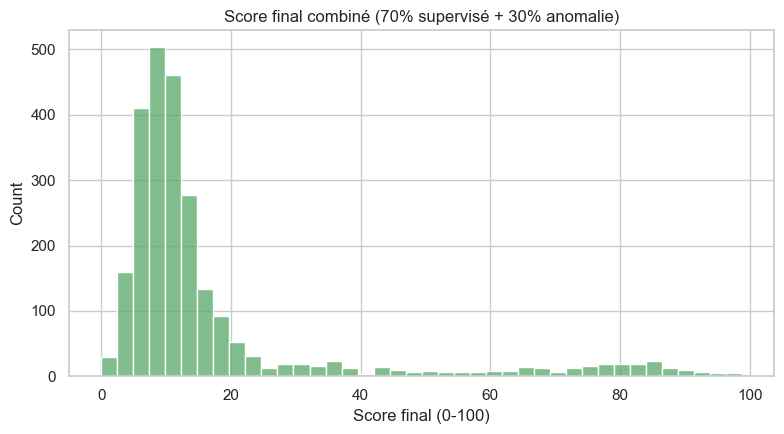

count    2503.0
mean       17.3
std        19.6
min         0.0
25%         7.6
50%        10.7
75%        15.5
max        98.8
dtype: float64


In [1230]:
POIDS_SUPERVISE, POIDS_ANOMALIE = 0.7, 0.3
final_score = np.round(POIDS_SUPERVISE * fraud_score + POIDS_ANOMALIE * anomaly_score, 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(final_score, bins=40, color="#55A868", ax=ax)
ax.set_xlabel("Score final (0-100)")
ax.set_title(f"Score final combiné ({POIDS_SUPERVISE:.0%} supervisé + {POIDS_ANOMALIE:.0%} anomalie)")
plt.tight_layout()
plt.show()
print(pd.Series(final_score).describe().round(1))


## 15. Segmentation opérationnelle

                      nb_dossiers  taux_fraude_reel
segment                                            
Faible risque                1741             0.010
Risque intermédiaire          511             0.078
Risque élevé                  251             0.542


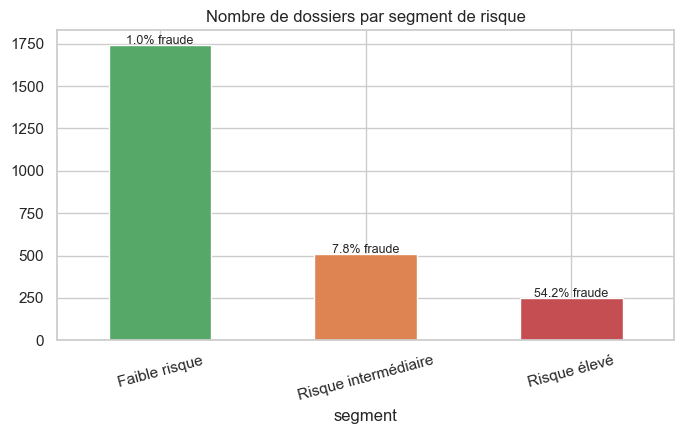

In [1231]:
PART_ELEVE = 0.10
PART_INTERMEDIAIRE = 0.20

SEUIL_ELEVE = float(np.percentile(final_score, 100 * (1 - PART_ELEVE)))
SEUIL_INTERMEDIAIRE = float(np.percentile(final_score, 100 * (1 - PART_ELEVE - PART_INTERMEDIAIRE)))

def segmenter(score):
    if score >= SEUIL_ELEVE:
        return "Risque élevé"
    elif score >= SEUIL_INTERMEDIAIRE:
        return "Risque intermédiaire"
    return "Faible risque"


segment = pd.Series(final_score).apply(segmenter)
segment_order = ["Faible risque", "Risque intermédiaire", "Risque élevé"]

recap = pd.DataFrame({"segment": segment, "fraude_reelle": y_test.values})
tab = recap.groupby("segment")["fraude_reelle"].agg(["count", "mean"]).reindex(segment_order)
tab.columns = ["nb_dossiers", "taux_fraude_reel"]
print(tab.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"Faible risque": "#55A868", "Risque intermédiaire": "#DD8452", "Risque élevé": "#C44E52"}
tab["nb_dossiers"].plot(kind="bar", ax=ax, color=[colors[s] for s in tab.index])
ax.set_title("Nombre de dossiers par segment de risque")
ax.tick_params(axis="x", rotation=15)
for i, (n, t) in enumerate(zip(tab["nb_dossiers"], tab["taux_fraude_reel"])):
    ax.text(i, n + 5, f"{t:.1%} fraude", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("segmentation_risques.png", bbox_inches="tight")
plt.show()


## 16. Gain économique 

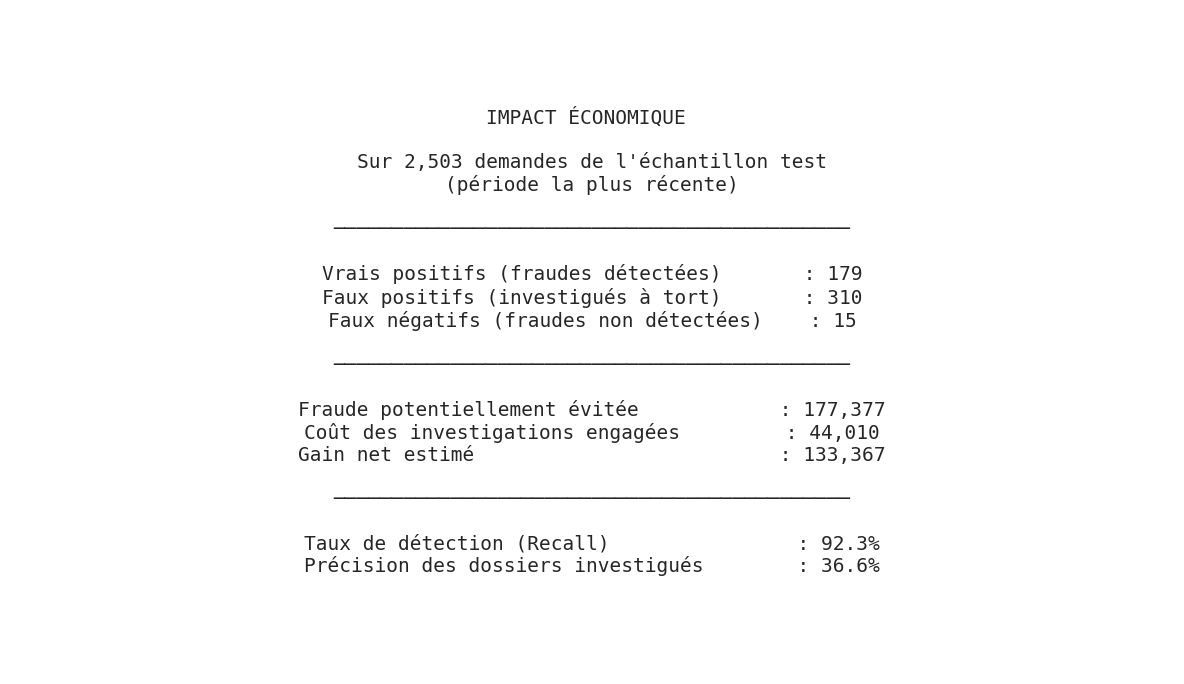

In [1232]:
pred_final = (best_proba >= seuil_optimal).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_final).ravel()

cout_moyen_fraude = df.loc[df["Is_Fraud"] == 1, "Claim_Amount"].mean()
cout_investigation = 90

fraude_evitee = tp * cout_moyen_fraude
cout_investigations_total = (tp + fp) * cout_investigation
gain_net = fraude_evitee - cout_investigations_total

texte = f"""
IMPACT ÉCONOMIQUE 

Sur {len(y_test):,} demandes de l'échantillon test
(période la plus récente)

────────────────────────────────────────────

Vrais positifs (fraudes détectées)       : {tp}
Faux positifs (investigués à tort)       : {fp}
Faux négatifs (fraudes non détectées)    : {fn}

────────────────────────────────────────────

Fraude potentiellement évitée            : {fraude_evitee:,.0f}
Coût des investigations engagées         : {cout_investigations_total:,.0f}
Gain net estimé                          : {gain_net:,.0f}

────────────────────────────────────────────

Taux de détection (Recall)                : {tp/(tp+fn):.1%}
Précision des dossiers investigués        : {tp/(tp+fp):.1%}
"""

fig, ax = plt.subplots(figsize=(12, 7))

ax.text(0.5, 0.5,
        texte,
        ha="center", va="center",
        fontsize=14,
        family="monospace",
        transform=ax.transAxes
)

ax.axis("off")
plt.tight_layout()
plt.savefig("impact_economique_fraude.png",
            dpi=170,
            bbox_inches="tight"
)

plt.show()


## 20. Application : Scorer un nouveau dossier 

In [1233]:
def scorer_nouveau_dossier(Patient_Age, Claim_Amount, Days_Between_Service_and_Claim,
                           Number_of_Claims_Per_Provider_Monthly, Length_of_Stay, Chronic_Condition_Flag,
                           Prior_Visits_12m, Procedure_Code, Provider_ID,
                           Patient_Gender, Insurance_Type, Provider_Specialty, Visit_Type,
                           Patient_State, Diagnosis_Code,
                           afficher=True, ):
    
    # Feature engineering (mêmes règles qu'à l'entraînement, statistiques figées sur le train)
    med_procedure = ref_stats["median_amount_by_procedure"].get(Procedure_Code, ref_stats["median_amount_by_procedure"].median())
    montant_vs_profil_procedure = Claim_Amount / med_procedure
    provider_taux_fraude_hist = ref_stats["provider_fraud_rate"].get(Provider_ID, ref_stats["global_fraud_rate"])
    provider_volume_hist = ref_stats["provider_volume"].get(Provider_ID, 0)
    provider_connu = Provider_ID in ref_stats["provider_fraud_rate"].index

    dossier = pd.DataFrame([{"Patient_Age": Patient_Age, "Claim_Amount": Claim_Amount,
                             "Days_Between_Service_and_Claim": Days_Between_Service_and_Claim,
                             "Number_of_Claims_Per_Provider_Monthly": Number_of_Claims_Per_Provider_Monthly,
                             "Length_of_Stay": Length_of_Stay, "Chronic_Condition_Flag": Chronic_Condition_Flag,
                             "Prior_Visits_12m": Prior_Visits_12m,
                             "montant_vs_profil_procedure": montant_vs_profil_procedure,
                             "provider_taux_fraude_hist": provider_taux_fraude_hist,
                             "provider_volume_hist": provider_volume_hist,
                             "Patient_Gender": Patient_Gender, "Insurance_Type": Insurance_Type,
                             "Provider_Specialty": Provider_Specialty, "Visit_Type": Visit_Type,
                             "Patient_State": Patient_State, "Diagnosis_Code": Diagnosis_Code,
    }])[num_features + cat_features]

    # Score supervisé
    proba = best_pipe.predict_proba(dossier)[0, 1]
    score_supervise = round(proba * 100, 1)

    # Score d'anomalie (normalise avec les memes bornes que sur l'echantillon test)
    dossier_enc = prep_fitted.transform(dossier)
    raw = -iso_forest.score_samples(dossier_enc)[0]
    score_anomalie = float(np.clip((raw - raw_anomaly.min()) / (raw_anomaly.max() - raw_anomaly.min()) * 100, 0, 100))

    # Score final et decision (bandes calees sur la distribution du score)
    score_final = round(POIDS_SUPERVISE * score_supervise + POIDS_ANOMALIE * score_anomalie, 1)
    segment = segmenter(score_final)
    prediction = int(segment == "Risque élevé")
    action = {"Faible risque": "Traitement automatique",
              "Risque intermédiaire": "Contrôle léger (vérification documentaire)",
              "Risque élevé": "Investigation approfondie"}[segment]

    # Facteurs explicatifs (comparaison aux medianes du train)
    references = {"Days_Between_Service_and_Claim": (df_train["Days_Between_Service_and_Claim"].median(), "délai de facturation court", True),
                  "Claim_Amount": (df_train["Claim_Amount"].median(), "montant facturé élevé", False),
                  "provider_taux_fraude_hist": (df_train["provider_taux_fraude_hist"].median(), "professionnel à historique de fraude élevé", False),
                  "montant_vs_profil_procedure": (1.0, "montant élevé vs profil de l'acte", False),
    }
    valeurs = {"Days_Between_Service_and_Claim": Days_Between_Service_and_Claim, "Claim_Amount": Claim_Amount,
               "provider_taux_fraude_hist": provider_taux_fraude_hist,
               "montant_vs_profil_procedure": montant_vs_profil_procedure}
    raisons = []
    for var, (ref, label, inverse) in references.items():
        val = valeurs[var]
        ecart = (ref - val) if inverse else (val - ref)
        if ecart > 0:
            raisons.append((ecart / (abs(ref) + 1e-6), f"{label} (valeur={val:.1f}, référence={ref:.1f})"))

    if not provider_connu:
        raisons.append((0.05, "professionnel absent de l'historique d'entraînement (pas de recul)"))
    raisons.sort(reverse=True)

    resultat = {"score_supervise": score_supervise, "score_anomalie": round(score_anomalie, 1),
                "score_final": score_final, "segment": segment, "prediction_fraude": prediction,
                "action_recommandee": action, "principaux_facteurs": [r[1] for r in raisons[:4]],
    }




    if afficher:

        couleurs = {"Faible risque": "#2E7D32",          
                    "Risque intermédiaire": "#EF6C00",   
                    "Risque élevé": "#C62828"           
        }

        couleur_risque = couleurs[segment]

        statuts = {"Faible risque": "RISQUE FAIBLE",
                   "Risque intermédiaire": "RISQUE INTERMÉDIAIRE",
                   "Risque élevé": "RISQUE ÉLEVÉ"
        }

        statut = statuts[segment]


        # Médianes et Références
        mediane_montant = df_train["Claim_Amount"].median()
        mediane_delai = df_train["Days_Between_Service_and_Claim"].median()


        facteurs_affichage = []

        for facteur in resultat["principaux_facteurs"]:

                # Historique de fraude du professionnel
                if facteur.startswith("professionnel à historique de fraude élevé"):
                   facteurs_affichage.append(f"• Historique de fraude du professionnel élevé "
                                             f"({provider_taux_fraude_hist:.1%})"
                   )

                # Montant par rapport au profil de l'acte
                elif facteur.startswith("montant élevé vs profil de l'acte"):
                     facteurs_affichage.append(f"• Montant facturé "
                                               f"{montant_vs_profil_procedure:.1f}× "
                                               f"la médiane observée pour cet acte"
                   )

                # Montant facturé élevé
                elif facteur.startswith("montant facturé élevé"):
                   facteurs_affichage.append(
                        f"• Montant facturé élevé "
                        f"({Claim_Amount:,.0f} € "
                        f"vs médiane {mediane_montant:,.0f} €)"
                   )

                # Délai de facturation court
                elif facteur.startswith("délai de facturation court"):
                   facteurs_affichage.append(f"• Délai de facturation court "
                                             f"({Days_Between_Service_and_Claim:.0f} jours "
                                             f"vs médiane {mediane_delai:.0f} jours)"
                   )

                # Autre facteur éventuel
                else:
                    facteurs_affichage.append(f"• {facteur}")


        # Si aucun facteur n'est identifié
        if len(facteurs_affichage) == 0:
            facteurs_affichage.append("• Aucun facteur de risque majeur identifié")


        facteurs_texte = "\n".join(facteurs_affichage)

        informations = (f"Montant facturé       : {Claim_Amount:,.2f} €\n"
                        f"Délai de facturation  : {Days_Between_Service_and_Claim:.0f} jours\n"
                        f"Professionnel         : {Provider_ID}\n"
                        f"Historique fraude     : {provider_taux_fraude_hist:.1%}\n"
                        f"Type de visite        : {Visit_Type}"
        )

        prediction_texte = ("OUI" if prediction else "NON")


        fig, ax = plt.subplots(figsize=(12, 8))

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.axis("off")

        cadre = plt.Rectangle((0.05, 0.05),
                               0.90, 0.90,
                               fill=False,
                               linewidth=2,
                               edgecolor="#333333"
        )

        ax.add_patch(cadre)

        ax.text(0.50, 0.915,
                "SYSTÈME DE DÉTECTION DE FRAUDE",
                ha="center", va="center",
                fontsize=20,
                fontweight="bold"
        )

        ax.text(0.50, 0.875,
                "Assurance santé",
                ha="center", va="center",
                fontsize=12
        )

        score_box = plt.Rectangle((0.30, 0.69),
                                   0.40, 0.145,
                                   facecolor=couleur_risque,
                                   edgecolor=couleur_risque,
                                   linewidth=2
        )

        ax.add_patch(score_box)

        ax.text(0.50, 0.805,
                "FRAUD SCORE",
                ha="center", va="center",
                fontsize=11,
                color="white",
                fontweight="bold"
        )

        ax.text(0.50, 0.755,
                f"{score_final:.0f} / 100",
                ha="center", va="center",
                fontsize=25,
                color="white",
                fontweight="bold"
        )

        ax.text(0.50, 0.715,
                statut,
                ha="center", va="center",
                fontsize=11,
                color="white",
                fontweight="bold"
        )

        ax.text(0.10, 0.635,
                "INFORMATIONS DU DOSSIER",
                ha="left",
                va="top",
                fontsize=12,
                fontweight="bold"
        )

        ax.text(0.10, 0.595,
                informations,
                ha="left", va="top",
                fontsize=11.5,
                family="monospace",
                linespacing=1.45
        )

        ax.plot([0.08, 0.92],
                [0.415, 0.415],
                linewidth=1
        )

        ax.text(0.10, 0.400,
                "PRINCIPAUX FACTEURS DE RISQUE",
                ha="left", va="top",
                fontsize=12,
                fontweight="bold"
        )

        ax.text(0.10, 0.365,
                facteurs_texte,
                ha="left", va="top",
                fontsize=10.5,
                linespacing=1.55
        )

        ax.plot([0.08, 0.92],
                [0.205, 0.205],
                linewidth=1
        )

        ax.text(0.10, 0.17,
                f"PRÉDICTION FRAUDE : {prediction_texte}",
                ha="left", va="top",
                fontsize=11,
                fontweight="bold"
        )

        ax.text(0.10, 0.12,
                f"ACTION RECOMMANDÉE : {action}",
                ha="left", va="top",
                fontsize=11
        )

        os.makedirs("resultats_fraude", exist_ok=True)
        # Nom unique pour chaque dossier
        nom_fichier = f"resultats_fraude/dossier_{Provider_ID}_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')}.png"

        plt.savefig(nom_fichier,
                    dpi=300,
                    bbox_inches="tight",
                    facecolor="white"
        )
              

        plt.show()

    return resultat


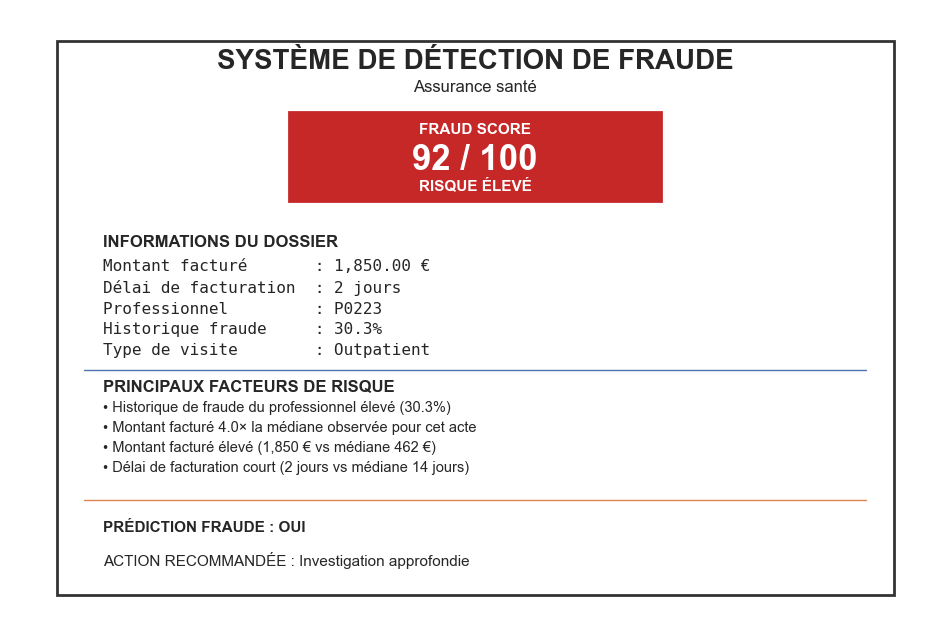

In [1234]:
# Exemple 1
_ = scorer_nouveau_dossier(Patient_Age=54,
                           Claim_Amount=1850.0,
                           Days_Between_Service_and_Claim=2,
                           Number_of_Claims_Per_Provider_Monthly=95,
                           Length_of_Stay=1,
                           Chronic_Condition_Flag=0,
                           Prior_Visits_12m=1,
                           Procedure_Code=df["Procedure_Code"].mode()[0],
                           Provider_ID=df["Provider_ID"].iloc[0],
                           Patient_Gender="F",
                           Insurance_Type="Private",
                           Provider_Specialty="General Practice",
                           Visit_Type="Outpatient",
                           Patient_State="CA",
                           Diagnosis_Code=df["Diagnosis_Code"].mode()[0],
)

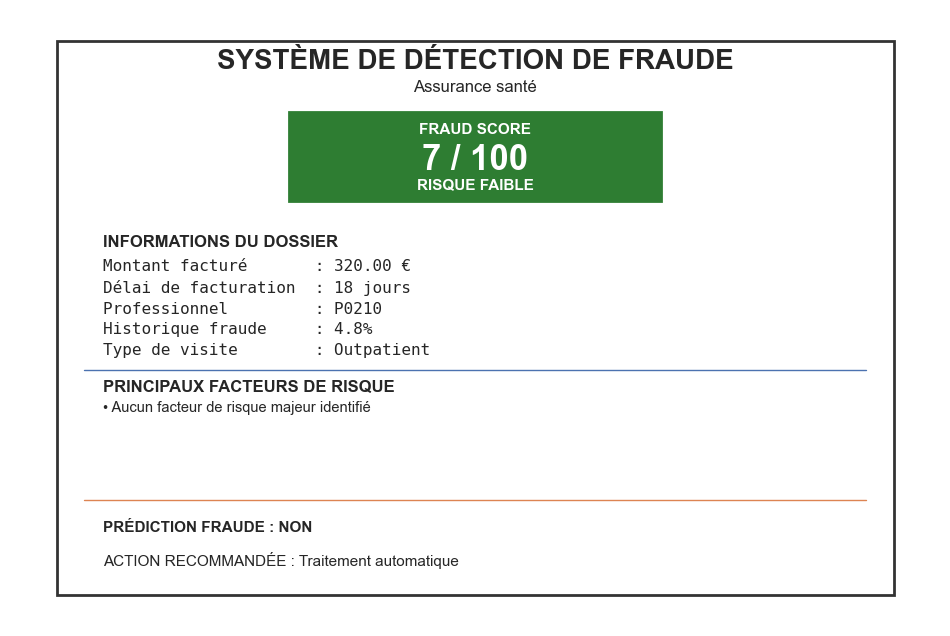

In [1235]:
# Exemple 2
_ = scorer_nouveau_dossier( Patient_Age=41,
                            Claim_Amount=320.0,
                            Days_Between_Service_and_Claim=18,
                            Number_of_Claims_Per_Provider_Monthly=20,
                            Length_of_Stay=0,
                            Chronic_Condition_Flag=0,
                            Prior_Visits_12m=3,
                            Procedure_Code=df["Procedure_Code"].mode()[0],
                            Provider_ID=df["Provider_ID"].iloc[10],
                            Patient_Gender="M",
                            Insurance_Type="Medicare",
                            Provider_Specialty="Cardiology",
                            Visit_Type="Outpatient",
                            Patient_State="NY",
                            Diagnosis_Code=df["Diagnosis_Code"].mode()[0],
)